In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
!pip install kagglehub[pandas-datasets]
import kagglehub
import os
path = kagglehub.competition_download('playground-series-s6e6')

print("Path to competition files:", path)

100%|██████████| 58.6M/58.6M [00:37<00:00, 1.62MB/s]

Extracting files...


Path to competition files: C:\Users\LENOVO\.cache\kagglehub\competitions\playground-series-s6e6


In [10]:
print(os.listdir(path))

['sample_submission.csv', 'test.csv', 'train.csv']


In [ ]:
train_path = os.path.join(path, "train.csv")
test_path = os.path.join(path, "test.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
print(train_df.shape)
print(test_df.shape)

train_df.head()

In [24]:
print(train_df.isnull().sum().sum())
print(test_df.isnull().sum().sum())
test_df.head()

0
0


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,577347,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,G/K,Red_Sequence
1,577348,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,M,Red_Sequence
2,577349,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,G/K,Blue_Cloud
3,577350,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,G/K,Red_Sequence
4,577351,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,M,Red_Sequence


In [25]:
target_col = [col for col in train_df.columns if col not in test_df.columns and col != 'id'][0]
print(f"Target Column Identified: '{target_col}'")
print("\nTarget Class Distribution:")
print(train_df[target_col].value_counts(normalize=True) * 100)

Target Column Identified: 'class'

Target Class Distribution:
class
GALAXY    65.381824
QSO       20.289878
STAR      14.328298
Name: proportion, dtype: float64


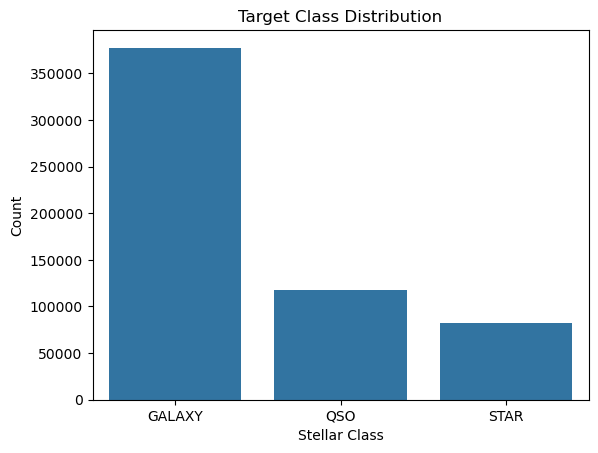

In [27]:
sns.countplot(data=train_df, x=target_col)
plt.title('Target Class Distribution')
plt.xlabel('Stellar Class')
plt.ylabel('Count')
plt.show()

In [32]:
from sklearn.preprocessing import LabelEncoder

def create_astronomical_features(df):
    df_feat = df.copy()
    
    df_feat['u_g'] = df_feat['u'] - df_feat['g']
    df_feat['g_r'] = df_feat['g'] - df_feat['r']
    df_feat['r_i'] = df_feat['r'] - df_feat['i']
    df_feat['i_z'] = df_feat['i'] - df_feat['z']
    df_feat['u_r'] = df_feat['u'] - df_feat['r']
    
    df_feat['ug_ratio'] = df_feat['u'] / (df_feat['g'] + 1e-6)
    df_feat['gr_ratio'] = df_feat['g'] / (df_feat['r'] + 1e-6)
    
    return df_feat

train_fe = create_astronomical_features(train_df)
test_fe = create_astronomical_features(test_df)

X = train_fe.drop(columns=['id', 'class'])
y_raw = train_fe['class']
X_test_final = test_fe.drop(columns=['id'])
X = pd.get_dummies(X, columns=['spectral_type', 'galaxy_population'], drop_first=True)
X_test_final = pd.get_dummies(X_test_final, columns=['spectral_type', 'galaxy_population'], drop_first=True)
X, X_test_final = X.align(X_test_final, join='left', axis=1, fill_value=0)

label_enc = LabelEncoder()
y = label_enc.fit_transform(y_raw)

In [ ]:
print(f"Processed Train Shape: {X.shape} | Processed Test Shape: {X_test_final.shape}")

Processed Train Shape: {X.shape} | Processed Test Shape: {X_test_final.shape}
